# Cost Prediction Regression

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

## 2. Load Processed Dataset

In [2]:
df = pd.read_csv("../data/processed/member_analysis_ready.csv") # Load the dataset
df.head() # Display the first few rows of the dataset


,member_id,age,gender,region,plan_type,sdoh_risk_score,chronic_condition_count,engagement_score,pcp_attributed_24mo,prior_awv_count,...,engagement_group,age_group,high_cost_member,chronic_burden_group,sdoh_risk_group,prior_awv_group,total_acute_visits,acute_utilization_group,pcp_status,has_acute_utilization
0,M00001,69,Male,Suburban,Medicare Advantage,40.7,2,68.9,1,1,...,Q4_High,65-79,1,Moderate,Q1_Low,1,2,Low,Attributed,1
1,M00002,32,Female,Urban,DSNP,80.0,3,30.4,0,0,...,Q1_Low,18-34,0,Moderate,Q4_High,0,2,Low,Not Attributed,1
2,M00003,89,Female,Suburban,Medicare Advantage,49.6,3,86.3,1,3,...,Q4_High,80+,0,Moderate,Q2,3,0,NaN,Attributed,0
3,M00004,78,Male,Suburban,Medicare Advantage,45.7,4,63.1,1,1,...,Q4_High,65-79,1,High,Q1_Low,1,3,Moderate,Attributed,1
4,M00005,38,Male,Suburban,Medicare Advantage,32.4,0,55.6,0,0,...,Q4_High,35-49,0,Low,Q1_Low,0,0,NaN,Not Attributed,0


## 3. Define Target and Features

In [3]:
target = "monthly_cost"  # Define the regression target variable

drop_cols = [
    "member_id",  # Identifier, not a real predictive feature
    target,  # Target variable must be removed from predictors
    "high_cost_member",  # Derived from monthly_cost, so this would leak target information
    "awv_completed"  # AWV outcome is better excluded from baseline cost prediction for cleaner modeling logic
]

X = df.drop(columns=drop_cols)  # Create predictor dataset after removing identifier, target, and leakage-prone columns
y = df[target]  # Store monthly cost as the regression target

## 4. Prepare Modeling Data

In [4]:
categorical_cols = X.select_dtypes(
    include=["object", "string", "category", "bool"]  # Select categorical/text-like predictors
).columns.tolist()  # Store categorical column names as a list

numeric_cols = X.select_dtypes(
    include=["int64", "float64", "int32", "float32"]  # Select numeric predictors
).columns.tolist()  # Store numeric column names as a list

print("Categorical columns:", categorical_cols)
print("Numeric Columns:", numeric_cols)



Categorical columns: ['gender', 'region', 'plan_type', 'engagement_group', 'age_group', 'chronic_burden_group', 'sdoh_risk_group', 'acute_utilization_group', 'pcp_status']
Numeric Columns: ['age', 'sdoh_risk_score', 'chronic_condition_count', 'engagement_score', 'pcp_attributed_24mo', 'prior_awv_count', 'prior_awv_rate', 'ed_visits', 'ip_admits', 'prior_awv_group', 'total_acute_visits', 'has_acute_utilization']


In [5]:
# Build the preprocessing pipeline

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(drop="first", handle_unknown="ignore"),
            categorical_cols  # One-hot encode categorical predictors
        ),
        (
            "num",
            StandardScaler(),
            numeric_cols  # Standardize numeric predictors
        )
    ]
)


## 5. Train-Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # Split the data into training and testing sets

# No Stratify =  y because stratify is usually for classification targets & monthly_cost is continuous.

## 6. Build Baseline Linear Regression Model

In [7]:
lr_model = Pipeline(steps = [ ("preprocessor", preprocessor) , ("model", LinearRegression()) ]) # Create a pipeline that combines the preprocessor and the linear regression model

lr_model.fit(X_train, y_train) # Fit the model to the training data


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

## 7. Evaluate Regression Performance 

In [8]:
# Make Predictions

y_pred = lr_model.predict(X_test) # Predict the target variable for the test set

# Calculate Metrics

mae = mean_absolute_error(y_test, y_pred) # Calculate Mean Absolute Error
mse = mean_squared_error(y_test, y_pred) # Calculate Mean Squared Error
rmse = np.sqrt(mse) # Calculate Root Mean Squared Error
r2 = r2_score(y_test, y_pred) # Calculate R-squared

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R-Squared:", r2)







MAE: 363.40280054542774
MSE: 404221.6079323761
RMSE: 635.7842463700844
R-Squared: 0.7770070948048046


## 8. Interpret Regression Coefficients

In [9]:
ohe = lr_model.named_steps["preprocessor"].named_transformers_["cat"]
encoded_cat_features = ohe.get_feature_names_out(categorical_cols) # Get the names of the encoded categorical features
all_feature_names = list(encoded_cat_features) + numeric_cols # Combine encoded categorical feature names with numeric feature names

# Get Coefficients

coefficients = lr_model.named_steps["model"].coef_ # Get the coefficients from the linear regression model
coef_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Coefficient": coefficients
})

coef_df["absolute_coefficient"] = coef_df["Coefficient"].abs() # Calculate the absolute value of the coefficients
coef_df = coef_df.sort_values(by="absolute_coefficient", ascending=False) # Sort the coefficients by absolute value

coef_df.head(15)

,Feature,Coefficient,absolute_coefficient
13,chronic_burden_group_Moderate,-689.811774,689.811774
3,plan_type_Medicaid,-561.178020,561.178020
23,chronic_condition_count,523.976734,523.976734
12,chronic_burden_group_Low,-491.819329,491.819329
29,ip_admits,460.169140,460.169140
4,plan_type_Medicare Advantage,-415.857638,415.857638
31,total_acute_visits,265.946145,265.946145
5,engagement_group_Q2,-149.603009,149.603009
6,engagement_group_Q3,-135.519011,135.519011
2,region_Urban,-85.878264,85.878264


## 9. Review Predictions Errors

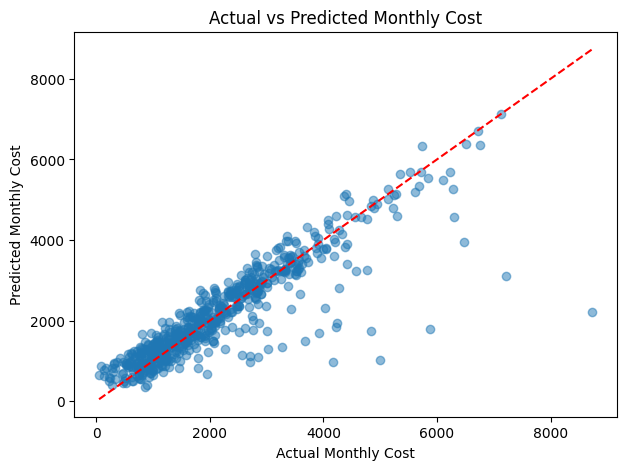

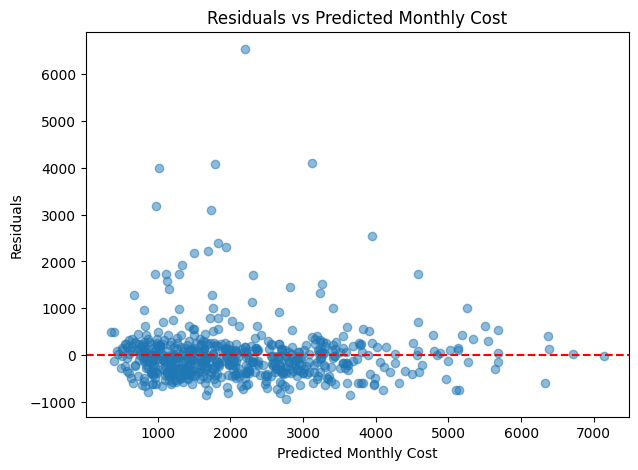

,actual_monthly_cost,predicted_monthly_cost,residual,absolute_error
415,8734.22,2204.449985,6529.770015,6529.770015
184,7218.17,3119.790564,4098.379436,4098.379436
160,5879.72,1794.186383,4085.533617,4085.533617
8,5004.13,1016.252765,3987.877235,3987.877235
225,4163.09,975.504407,3187.585593,3187.585593
102,4841.47,1738.426734,3103.043266,3103.043266
188,6484.28,3948.068963,2536.211037,2536.211037
410,4215.42,1831.992415,2383.427585,2383.427585
104,4247.30,1946.963118,2300.336882,2300.336882
116,3920.62,1687.965555,2232.654445,2232.654445


In [10]:
# Actual vs Predicted Scatter Plot

plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred, alpha=0.5) # Create a scatter plot of actual vs predicted values
plt.xlabel("Actual Monthly Cost") # Label for x-axis
plt.ylabel("Predicted Monthly Cost") # Label for y-axis
plt.title("Actual vs Predicted Monthly Cost") # Title for the plot
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--') # Add a reference line for perfect predictions
plt.show()

# Residuals Plot
residuals = y_test - y_pred # Calculate residuals
plt.figure(figsize=(7,5))
plt.axhline(0, color='red', linestyle='--') # Add a horizontal line at y=0
plt.scatter(y_pred, residuals, alpha=0.5) # Create a scatter plot of predicted values vs residuals
plt.xlabel("Predicted Monthly Cost") # Label for x-axis
plt.ylabel("Residuals") # Label for y-axis
plt.title("Residuals vs Predicted Monthly Cost") # Title for the plot
plt.show()

# Compare a few predictions 

comparison_df = pd.DataFrame({
    "actual_monthly_cost": y_test.values,  # Actual monthly cost values
    "predicted_monthly_cost": y_pred,  # Predicted monthly cost values
    "residual": y_test.values - y_pred,  # Actual minus predicted
    "absolute_error": np.abs(y_test.values - y_pred)  # Error size regardless of direction
})

comparison_df.sort_values(
    "absolute_error",  # Sort by largest prediction error
    ascending=False  # Show largest errors first
).head(10)



## 10. Findings

The purpose of this notebook was to build a baseline multiple linear regression model to predict monthly member cost.

The target variable was `monthly_cost`.

The predictor set excluded `member_id`, `high_cost_member`, and `awv_completed`. `member_id` was excluded because it is only an identifier. `high_cost_member` was excluded because it is derived from the cost target and would create target leakage. `awv_completed` was excluded to keep the baseline cost prediction model focused on member characteristics, risk, access, and utilization rather than using the AWV outcome as a predictor.

Categorical variables were one-hot encoded, and numeric variables were standardized.

Model performance was evaluated using MAE, MSE, RMSE, and R². MAE shows the average absolute prediction error, while RMSE penalizes larger errors more heavily. R² shows the share of cost variation explained by the model.

Regression coefficients describe conditional associations with predicted monthly cost, holding other included variables constant. Because numeric predictors were standardized, numeric coefficients represent the expected change in predicted monthly cost for a one-standard-deviation increase in the predictor. Dummy-variable coefficients represent differences relative to the omitted reference category.

The residual plots were used to check whether prediction errors were randomly scattered or whether the model showed systematic error patterns, such as underprediction among high-cost members.

Because this is synthetic data, the observed relationships reflect the assumptions built into the data-generation process and should not be interpreted as real-world causal evidence.